Importamos pandas y leemos los datos

In [1]:
import pandas as pd
datos = pd.read_csv("Titanic-Dataset.csv")

In [2]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Usamos esto para ver mas datos

In [3]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Importamos seaborn para poder hacer una grafica que nos diga cuantas personas sobrevivieron y cuantas no, usaremos countplot

<Axes: xlabel='Survived', ylabel='count'>

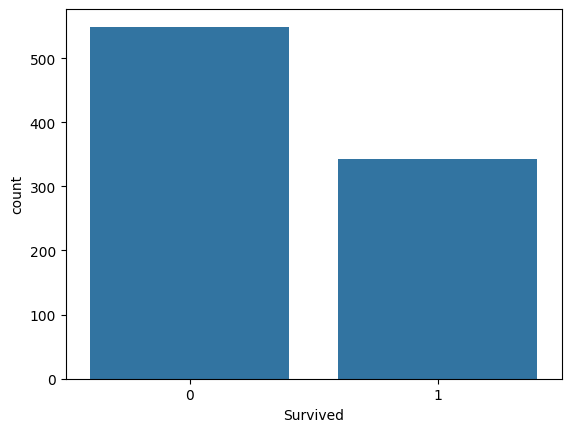

In [4]:
import seaborn as sb
sb.countplot(x="Survived", data=datos)

Ahora usamos hue en la misma grafica para que separe los géneros

<Axes: xlabel='Survived', ylabel='count'>

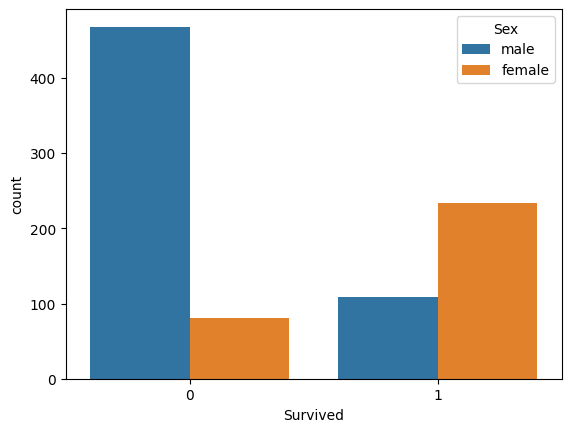

In [5]:
sb.countplot(x="Survived", data=datos, hue="Sex")

Con esta linea veremos los datos vacios usamdo sum para que haya una suma total de datos

In [6]:
datos.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
datos.isna(). sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Haremos una nueva grafica usando displot

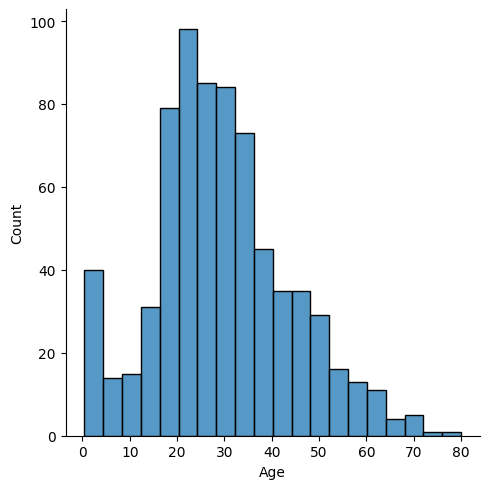

In [8]:
sb.displot(x="Age", data=datos)

Ahora haremos un proceso para que los 177 datos de AGE que estan vacios de se llenen con promedios de edad para no eliminarlos

Usamos esta linea para mostrar solo las edades

In [9]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


Y ahora sacamos el promedio usando mean

In [10]:
datos["Age"]. mean()

np.float64(29.69911764705882)

Ahora usaremos fillna para llenar los datos

In [11]:
datos["Age"].fillna(datos["Age"]. mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Como podemos ver en el numero 888 ya se integro pero si volvemos a correr esta linea datos["Age"] veremos que no se ha actualizado


In [12]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


Ahora vamos a actualizar los datos Age para que aparesca el promedio

In [13]:
datos["Age"] = datos["Age"].fillna(datos["Age"]. mean())

Ahora si aparece

In [14]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Y al volver a correr datos.isna().sum() veremos que ya se corrigio en la parte de Age

In [15]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Vamos a quitar la seccion de cabina

In [16]:
datos = datos.drop(["Cabin"], axis=1)

Y al volver a correr datos.isna().sum() veremos que se elimino

In [17]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Ahora veremos lo de embarcacion

In [18]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


Y quitaremos los dos que no tienen datos

In [19]:
datos = datos.dropna()

Y al correr este lina de nuevo datos.isna().sum() veremos otro resultado

In [20]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Ahora vamos a quitar PassengerId, Name y Ticket. Los quitaremos todos de una

In [21]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

Y al volver a correr datos.head() veremos que ya no estan

In [22]:
datos.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Ahora convertiremos la columna de sexo en numerica

In [23]:
pd.get_dummies(datos["Sex"], drop_first=True)

,male
0,True
1,False
2,False
3,False
4,True
...,...
886,True
887,False
888,False
889,True


Ahora lo guardamos en una variable

In [24]:
dummies_sex = pd.get_dummies(datos["Sex"], drop_first=True)

Y lo agregamos a nuestro conjunto y quitamos de una vez la columna sex

In [25]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"], axis=1)

Y si vemos de nuevo el cojunto

In [26]:
datos.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male
0,0,3,22.0,1,0,7.2500,S,True
1,1,1,38.0,1,0,71.2833,C,False
2,1,3,26.0,0,0,7.9250,S,False
3,1,1,35.0,1,0,53.1000,S,False
4,0,3,35.0,0,0,8.0500,S,True


Hacemos una grafica de Embarked para ver si es relevante tener la columna

<Axes: xlabel='Survived', ylabel='count'>

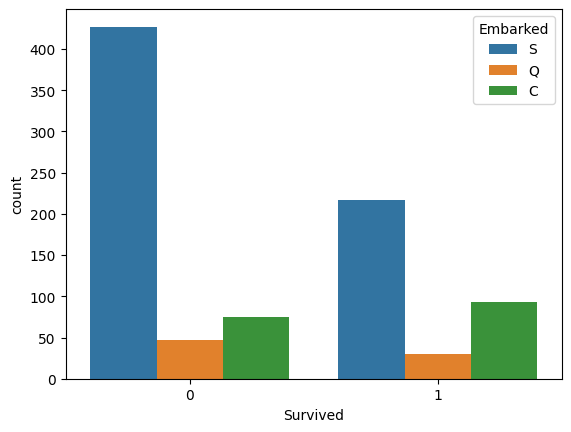

In [27]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

Haremos lo mismo que hcimos arriba

In [28]:
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

In [29]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

Y si vemos el conjunto ya no estara Embarked

In [30]:
datos.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Y hacemos un heatmap para ver la correlacion

<Axes: >

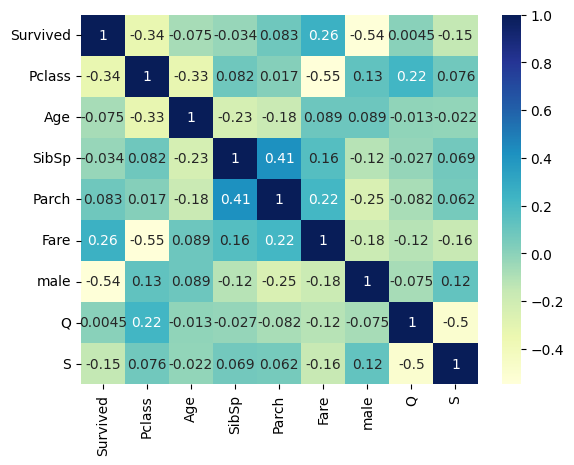

In [31]:
sb.heatmap(datos.corr(), annot=True, cmap="YlGnBu")

Ahora haremos otra grafica que muestra que entre menor numero de clase mas probabilidad de sobrevivir habia

<Axes: xlabel='Survived', ylabel='count'>

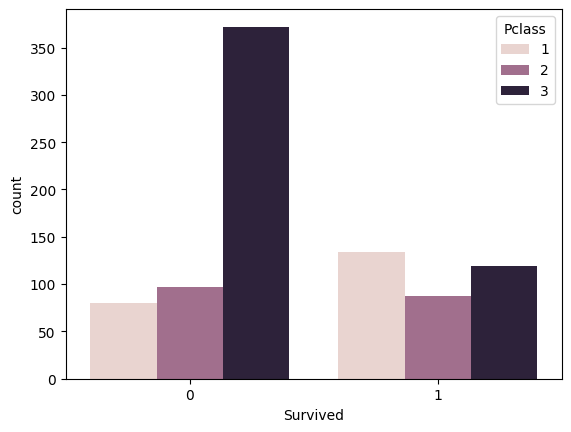

In [32]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

Ahora empezamos el entrenamiento

In [33]:
X = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

Separamos los datos

In [34]:
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=.2)

# AQUI EMPIEZA EL NUEVO VIDEO

Aqui generamos el modelo con DecisionTreeClassifier y de una vez seleccionamos las predicciones

In [39]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.8426966292134831

Ahora haremos varios modelos para ver la diferencia de profundidades

In [42]:
from sklearn.tree import DecisionTreeClassifier

for i in range(1,10):
  modelo = DecisionTreeClassifier(max_depth=50)
  modelo.fit(X_ent, y_ent)
  predicciones = modelo.predict(X_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print(f"Resultado para {i}: {exactitud}")

Resultado para 1: 0.8202247191011236
Resultado para 2: 0.8146067415730337
Resultado para 3: 0.8033707865168539
Resultado para 4: 0.8146067415730337
Resultado para 5: 0.8202247191011236
Resultado para 6: 0.8033707865168539
Resultado para 7: 0.8146067415730337
Resultado para 8: 0.8146067415730337
Resultado para 9: 0.8033707865168539


Ahora con 15

In [43]:
from sklearn.tree import DecisionTreeClassifier

for i in range(1,15):
  modelo = DecisionTreeClassifier(max_depth=50)
  modelo.fit(X_ent, y_ent)
  predicciones = modelo.predict(X_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print(f"Resultado para {i}: {exactitud}")

Resultado para 1: 0.8146067415730337
Resultado para 2: 0.8033707865168539
Resultado para 3: 0.8146067415730337
Resultado para 4: 0.8146067415730337
Resultado para 5: 0.8033707865168539
Resultado para 6: 0.8146067415730337
Resultado para 7: 0.8202247191011236
Resultado para 8: 0.8146067415730337
Resultado para 9: 0.8089887640449438
Resultado para 10: 0.8202247191011236
Resultado para 11: 0.8146067415730337
Resultado para 12: 0.8146067415730337
Resultado para 13: 0.8202247191011236
Resultado para 14: 0.8202247191011236


Ahora guardaremos la exactitud en una lista llamada resultados y haremos una grafica

In [44]:
from sklearn.tree import DecisionTreeClassifier

resultados = []
for i in range(1,15):
  modelo = DecisionTreeClassifier(max_depth=50)
  modelo.fit(X_ent, y_ent)
  predicciones = modelo.predict(X_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print(f"Resultado para {i}: {exactitud}")
  resultados.append(exactitud)

Resultado para 1: 0.8202247191011236
Resultado para 2: 0.8202247191011236
Resultado para 3: 0.8033707865168539
Resultado para 4: 0.8033707865168539
Resultado para 5: 0.8202247191011236
Resultado para 6: 0.8202247191011236
Resultado para 7: 0.8089887640449438
Resultado para 8: 0.8146067415730337
Resultado para 9: 0.8202247191011236
Resultado para 10: 0.8089887640449438
Resultado para 11: 0.8202247191011236
Resultado para 12: 0.8089887640449438
Resultado para 13: 0.8202247191011236
Resultado para 14: 0.8202247191011236


<Axes: >

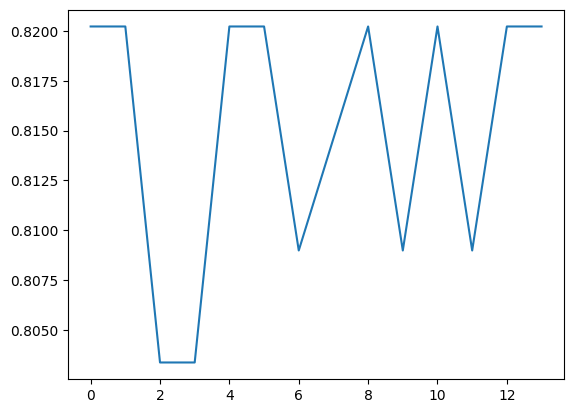

In [45]:
sb.lineplot(data=resultados)

Ahora continuaremos con nuestro modelo

In [46]:
modelo = DecisionTreeClassifier(max_depth=8)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)
exactitud = accuracy_score(y_pru, predicciones)

Vemos que mejoraron los resultados

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89       112
           1       0.82      0.77      0.80        66

    accuracy                           0.85       178
   macro avg       0.85      0.84      0.84       178
weighted avg       0.85      0.85      0.85       178



In [48]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,Pred: No,Pred: Si
Real: No,101,11
Real: Si,15,51


Ahora graficaremos el árbol

[Text(0.43083333333333335, 0.9444444444444444, 'male <= 0.5\n0.474\n711\n[437, 274]\nMurió'),
 Text(0.16666666666666666, 0.8333333333333334, 'Pclass <= 2.5\n0.407\n246\n[70, 176]\nVivió'),
 Text(0.29875, 0.8888888888888888, 'True  '),
 Text(0.07333333333333333, 0.7222222222222222, 'Age <= 2.5\n0.131\n128\n[9, 119]\nVivió'),
 Text(0.04, 0.6111111111111112, 'Parch <= 1.5\n0.5\n2\n[1, 1]\nMurió'),
 Text(0.02666666666666667, 0.5, '0.0\n1\n[0, 1]\nVivió'),
 Text(0.05333333333333334, 0.5, '0.0\n1\n[1, 0]\nMurió'),
 Text(0.10666666666666667, 0.6111111111111112, 'Fare <= 28.856\n0.119\n126\n[8, 118]\nVivió'),
 Text(0.08, 0.5, 'Age <= 56.0\n0.237\n51\n[7.0, 44.0]\nVivió'),
 Text(0.06666666666666667, 0.3888888888888889, 'Fare <= 28.231\n0.211\n50\n[6, 44]\nVivió'),
 Text(0.05333333333333334, 0.2777777777777778, 'SibSp <= 0.5\n0.183\n49\n[5, 44]\nVivió'),
 Text(0.02666666666666667, 0.16666666666666666, 'Fare <= 13.396\n0.108\n35\n[2, 33]\nVivió'),
 Text(0.013333333333333334, 0.05555555555555555, 

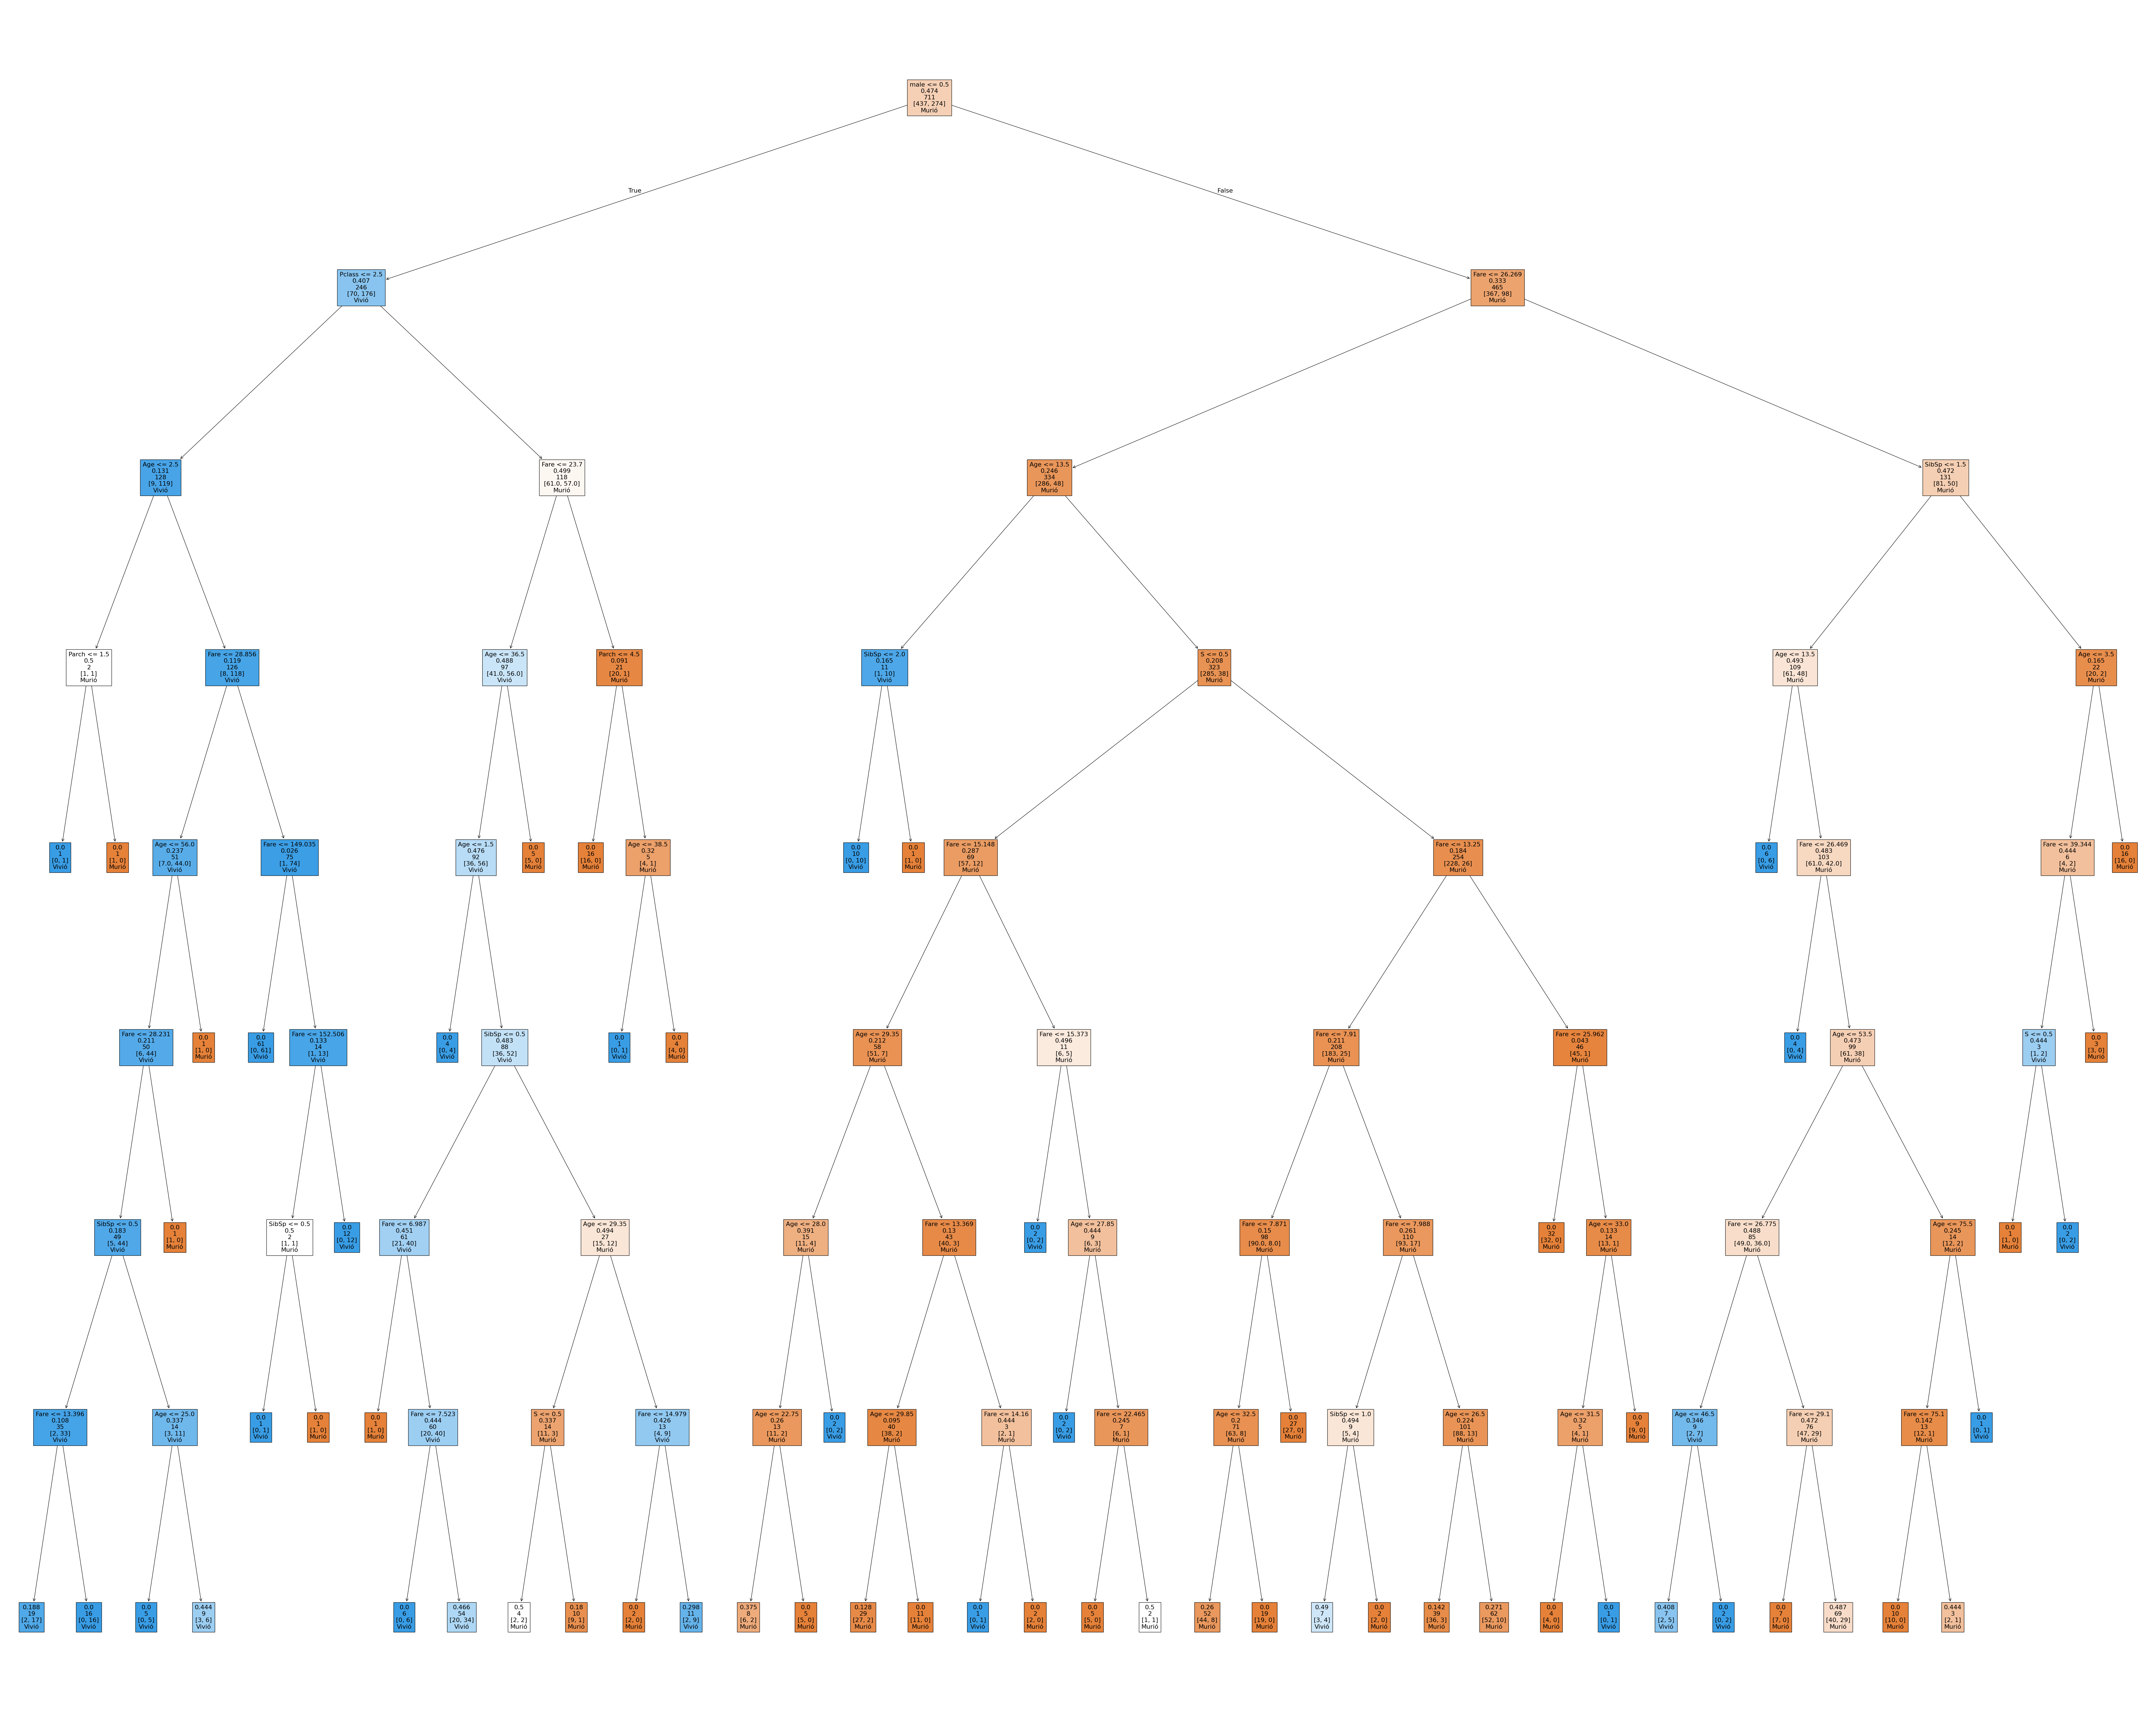

In [50]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100,80))
plot_tree(
    modelo,
    feature_names=X_ent.columns,
    class_names=["Murió", "Vivió"],
    filled=True, label="none"
)

# AQUI ACABA LO DE ARBOL DE DECISIONES

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.8202247191011236

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       109
           1       0.80      0.71      0.75        69

    accuracy                           0.82       178
   macro avg       0.82      0.80      0.81       178
weighted avg       0.82      0.82      0.82       178



In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[97, 12],
       [20, 49]])

Como en esta ultima celda no nos muestra casi nada haremos un dataframe

Aqui nos dice que cuando el modelo predijo que NO en 89 efectivamente no habian sobrevivido sin embargo en 25 habia dicho que no sobrevivian pero si sobrevivieron

Y cuando el modelo predijo que SI 17 no habian sobrevivido y 47 si

In [ ]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,Pred: No,Pred: Si
Real: No,97,12
Real: Si,20,49


Ahora me agregare para hacer una practica divertida para ver si sobreviviria segun la clase o algun otro elemento

In [ ]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [ ]:
nueva_persona = [3, 17, 0, 0, 10, 1, 0, 0]
prediccion = modelo.predict([nueva_persona])
if prediccion[0] == 1:
  print("Sobreviviste")
else:
  print("No sobreviviste")

No sobreviviste


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Aqui no sobreviviria

In [ ]:
nueva_persona = [1, 17, 0, 0, 80, 1, 0, 0]
prediccion = modelo.predict([nueva_persona])
if prediccion[0] == 1:
  print("Sobreviviste")
else:
  print("No sobreviviste")

Sobreviviste


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


En este caso si sobrevivi